A company invests money in different forms of advertising channels (TV, Radio, newspaper). Dataset includes monthly spend on each of the advertising channel and its respective sales.

The management wants to understand:
1)What advertising channel impacts the
product sales the most?
2)How does spending on each platform influence the sales?
3)What is the relationship between the most impactful advertising channel with respect to sales?
4)If they spend 50 cr on the best advertising channel, what will be the sales?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Advertising.csv.csv')

In [ ]:
### EDA

In [5]:
df.head()

,No,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
df.shape

(200, 5)

The dataset has 200 rows and 5 columns

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


All the columns have numerical data type (either float/int)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
No,200.0,100.5000,57.879185,1.0,50.750,100.50,150.250,200.0
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [9]:
## Drop "No." column as it has all the values in it as unique
df.drop('No', axis=1, inplace=True)

In [10]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [11]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [12]:
## Check duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
##  Split the dataset into categorical and numerical columns

cat = df.select_dtypes(include = "object").columns
num = df.select_dtypes(exclude= "object").columns

In [14]:
cat

Index([], dtype='object')

In [15]:
num

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [16]:
## Handling outliers using IQR

for col in df.columns:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  upper_limit = Q3 + 1.5 * IQR
  lower_limit = Q1 - 1.5 * IQR

  print(col)

  print("Lower limit: ", lower_limit)
  print("Upper limit: ", upper_limit)
  print("Outliers: ", df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0])
  print()

TV
Lower limit:  -142.29999999999998
Upper limit:  435.5
Outliers:  0

Radio
Lower limit:  -29.849999999999994
Upper limit:  76.35
Outliers:  0

Newspaper
Lower limit:  -35.775000000000006
Upper limit:  93.625
Outliers:  2

Sales
Lower limit:  -0.16249999999999787
Upper limit:  27.937499999999996
Outliers:  0



In [17]:
# We found 2 outliers in Newspaper column. now we need to elimate those

Q1_newspaper = df['Newspaper'].quantile(0.25)
Q3_newspaper = df['Newspaper'].quantile(0.75)
IQR_newspaper = Q3_newspaper - Q1_newspaper

upper_limit_newspaper = Q3_newspaper + 1.5 * IQR_newspaper
lower_limit_newspaper = Q1_newspaper - 1.5 * IQR_newspaper

print(f"Newspaper Lower Limit: {lower_limit_newspaper}")
print(f"Newspaper Upper Limit: {upper_limit_newspaper}")

df = df[(df['Newspaper'] >= lower_limit_newspaper) & (df['Newspaper'] <= upper_limit_newspaper)]

Newspaper Lower Limit: -35.775000000000006
Newspaper Upper Limit: 93.625


In [18]:
# The outliers in the 'Newspaper' column have been removed. Let's check the new shape of the DataFrame

df.shape

(198, 4)

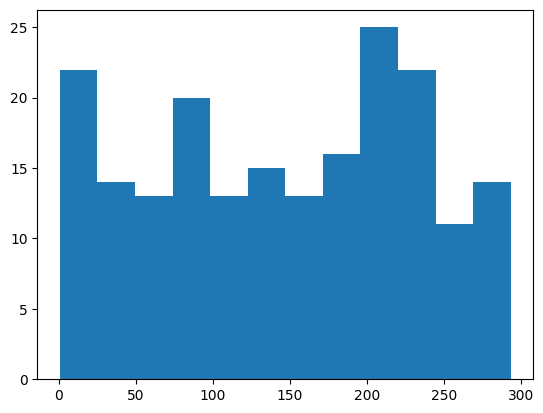

In [19]:
## Univariate analysis
plt.hist(df["TV"], bins=12)

plt.show()

TV


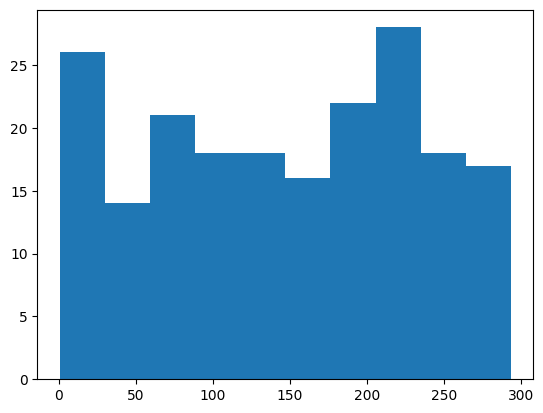

Radio


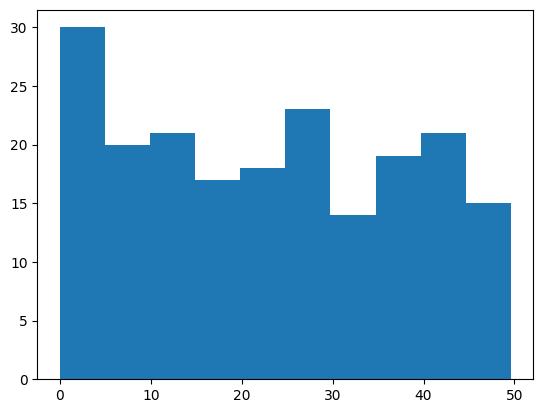

Newspaper


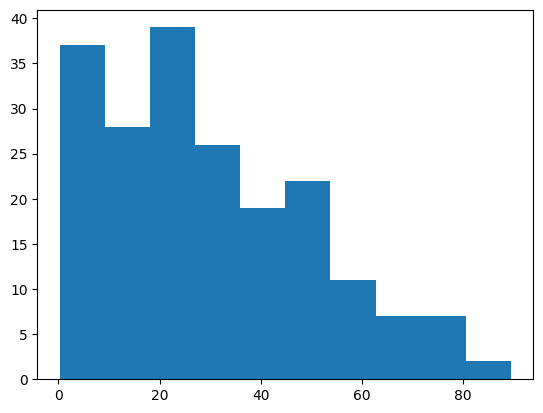

Sales


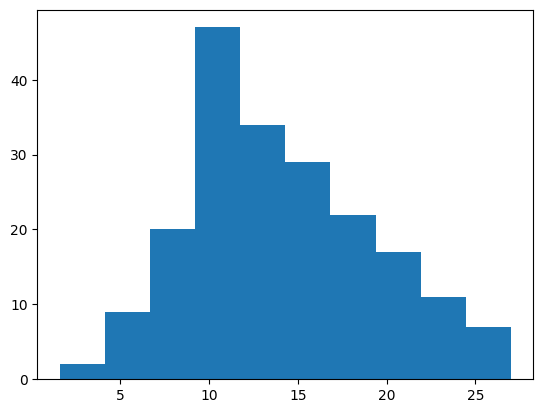

In [20]:
for i in df:
  print(i)
  plt.hist(df[i])
  plt.show()

In [ ]:
# Bivariate analysis
# Correlation analyis - it is a statistical method used to evaluate the strength and direction of the relationship between 2 continuous variables.

# It is calcuated using person correalation coefficient. and takes value between -1 to +1

# if the value is +1: it means the 2 variables have perfect positive linear relationship
# if the value is 0: it means there is no linear correlation
# if the value is -1: it means the 2 variables have perfect negative linear relationship

In [21]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.051978,0.049771,0.779121
Radio,0.051978,1.000000,0.346364,0.576748
Newspaper,0.049771,0.346364,1.000000,0.219555
Sales,0.779121,0.576748,0.219555,1.000000


In [ ]:
# this clearly indicates that TV is having highest impact on the sales

<Axes: >

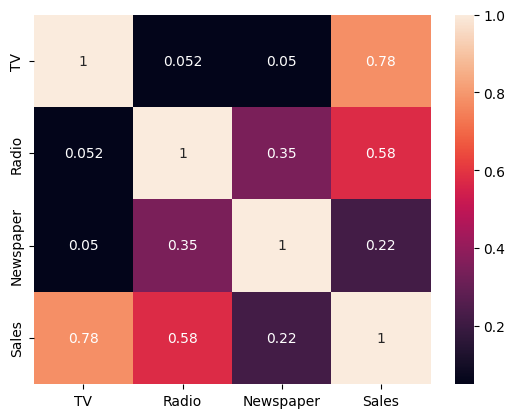

In [22]:
## heatmap
sns.heatmap(df.corr(), annot=True)

The management wants to understand:

What advertising channel impacts the product sales the most? - TV
How does spending on each platform influence the sales?
What is the relationship between the most impactful advertising channel with respect to sales? = With the positive linear relationship of 0.78

In [23]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


ML Model building

In [24]:
## Import all the libraries for ML part

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split  ##used to split the data into 4 parts: X_train, X_test, y_train, y_test

In [25]:
X = df['TV']
y = df['Sales']

In [27]:
X

,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8
...,...
195,38.2
196,94.2
197,177.0
198,283.6


In [29]:
y

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((158,), (40,), (158,), (40,))

The expression X_train.values.reshape(-1, 1) is used to convert a 1D array into a 2D array with exactly one column. Machine learning libraries like scikit-learn require features (X) to be structured as a 2D matrix (samples, features), even if you only have a single feature.

In [32]:
X_train = X_train.values.reshape(-1,1)

In [33]:
## Save the model into a variable

lr = LinearRegression()

In [34]:
## Model building

lr.fit(X_train, y_train)

LinearRegression()

In [35]:
## Model parameters: C (intercept), m (coeff)

print("Intercept: ", lr.intercept_)
print("Coefficient: ", lr.coef_)

Intercept:  7.067101760949088
Coefficient:  [0.04756599]


Therefore, the equation of best fit line is:

y = 0.046X + 7.05

In [36]:
X_test = X_test.values.reshape(-1,1)

In [37]:
y_pred = lr.predict(X_test)

In [38]:
y_pred

array([10.21121378,  7.26212232, 13.74061032, 12.92247527,  9.74031046,
       12.33265698, 13.22214102, 17.55540281, 20.41887548,  9.11243938,
       12.28984759,  7.32395811, 17.87409495, 12.58475674, 18.39732086,
       17.6457782 , 10.78676227, 20.8469694 , 19.21545591, 12.04250444,
       19.56268764, 16.28063425, 18.88249397, 16.5374906 , 10.88189425,
       17.92641754, 11.84272727, 14.89170731, 10.69638689, 16.36149644,
        7.69021625, 18.63515081, 19.68160262,  8.82228684, 10.70114349,
       15.66703296, 12.7988037 ,  8.28479113,  8.34187032, 20.89453539])

In [39]:
## Model evalaution

print("Mean squared error: ", mean_squared_error(y_test, y_pred))
print("Mean absolute error: ", mean_absolute_error(y_test, y_pred))
print("Root mean squared error: ", root_mean_squared_error(y_test, y_pred))
print("R2 score: ", r2_score(y_test, y_pred))

Mean squared error:  10.616913032921815
Mean absolute error:  2.622005496209308
Root mean squared error:  3.2583604823471903
R2 score:  0.6145078848326313


Which means that the model is trained with 65.13% accuracy


In [40]:
## As the problem suggests, we have to predict the output (Sales), when input is 50 Cr.

output = lr.predict([[50]])

In [41]:
output

array([9.44540132])

In [ ]:
# Therefore, if the input is 50 cr, output is 9.36 cr.